# step 1 loading the libraries

In [2]:
# ============================================================
# STEP 1: Install Required Libraries
# ============================================================
!pip install tensorflow wordcloud

# ─── Imports ─────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords

# Sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Embedding, LSTM, GRU, Dense, Dropout,
                                     Bidirectional, SpatialDropout1D,
                                     GlobalMaxPooling1D, Input)
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint,
                                         ReduceLROnPlateau)
from tensorflow.keras.utils import to_categorical

# Word Cloud
from wordcloud import WordCloud

# Fix random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("✅ All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


✅ All libraries imported successfully!
TensorFlow version: 2.19.0


## loading the data

In [3]:
# ============================================================
# STEP 0: Upload Dataset Files (like Hotel Reservations style)
# ============================================================
from google.colab import files
import pandas as pd

# Upload your files one by one (a file picker will appear)
uploaded = files.upload()  # Upload training.csv
uploaded = files.upload()  # Upload validation.csv
uploaded = files.upload()  # Upload test.csv

# Load directly by filename (same as your Hotel Reservations example)
train_df = pd.read_csv("training.csv")
val_df   = pd.read_csv("validation.csv")
test_df  = pd.read_csv("test.csv")

# Verify
print("Training shape   :", train_df.shape)
print("Validation shape :", val_df.shape)
print("Test shape       :", test_df.shape)

train_df.head()

Saving training.csv to training.csv


Saving validation.csv to validation.csv


Saving test.csv to test.csv
Training shape   : (16000, 2)
Validation shape : (2000, 2)
Test shape       : (2000, 2)


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


### Emotion Label Mapping

In [4]:
EMOTION_MAP = {
    0: 'Sadness',
    1: 'Joy',
    2: 'Love',
    3: 'Anger',
    4: 'Fear',
    5: 'Surprise'
}
COLORS = ['#3498db', '#f1c40f', '#e74c3c', '#e67e22', '#9b59b6', '#2ecc71']

# Add emotion name column for readability
train_df['emotion'] = train_df['label'].map(EMOTION_MAP)
val_df['emotion']   = val_df['label'].map(EMOTION_MAP)
test_df['emotion']  = test_df['label'].map(EMOTION_MAP)

print("\nFirst 5 rows of training data:")
display(train_df.head())

print("\nClass distribution in training set:")
print(train_df['emotion'].value_counts())


First 5 rows of training data:


,text,label,emotion
0,i didnt feel humiliated,0,Sadness
1,i can go from feeling so hopeless to so damned...,0,Sadness
2,im grabbing a minute to post i feel greedy wrong,3,Anger
3,i am ever feeling nostalgic about the fireplac...,2,Love
4,i am feeling grouchy,3,Anger



Class distribution in training set:
emotion
Joy         5362
Sadness     4666
Anger       2159
Fear        1937
Love        1304
Surprise     572
Name: count, dtype: int64


### Visualized class distributions

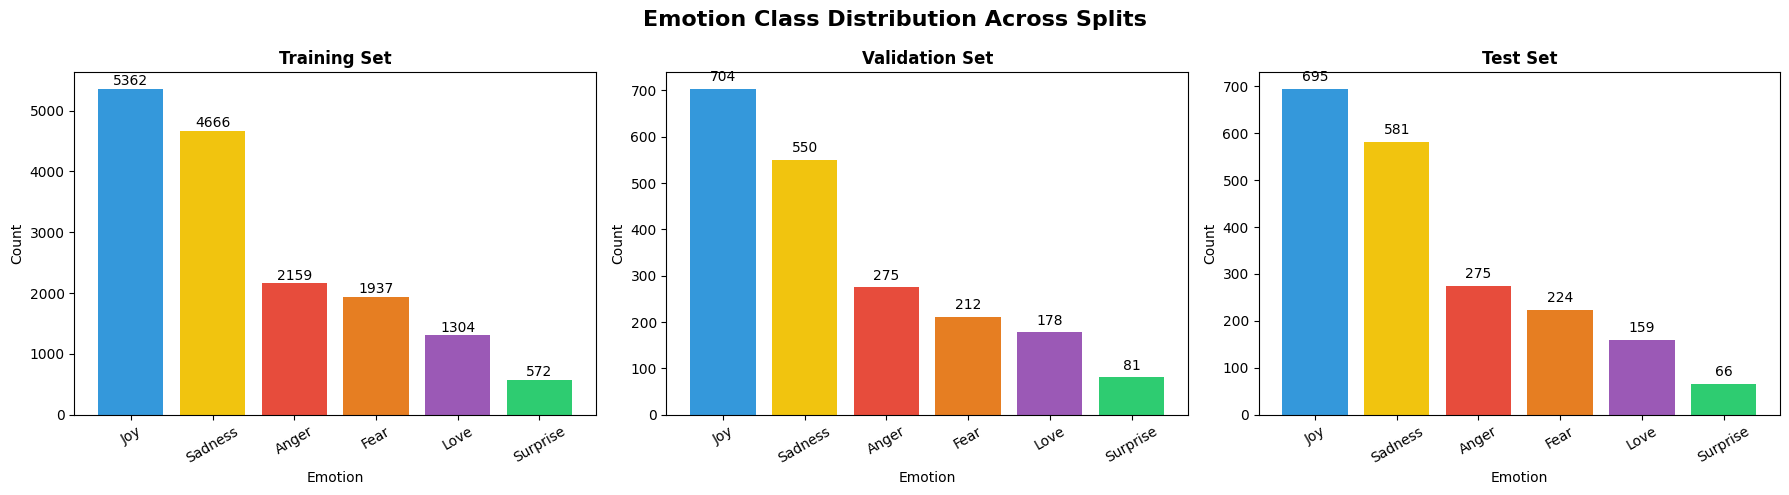

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Emotion Class Distribution Across Splits', fontsize=16, fontweight='bold')

for ax, (df, title) in zip(axes, [(train_df, 'Training'),
                                   (val_df,   'Validation'),
                                   (test_df,  'Test')]):
    counts = df['emotion'].value_counts()
    bars = ax.bar(counts.index, counts.values, color=COLORS[:len(counts)])
    ax.set_title(f'{title} Set', fontweight='bold')
    ax.set_xlabel('Emotion')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 10,
                str(val), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Text Length Analysis

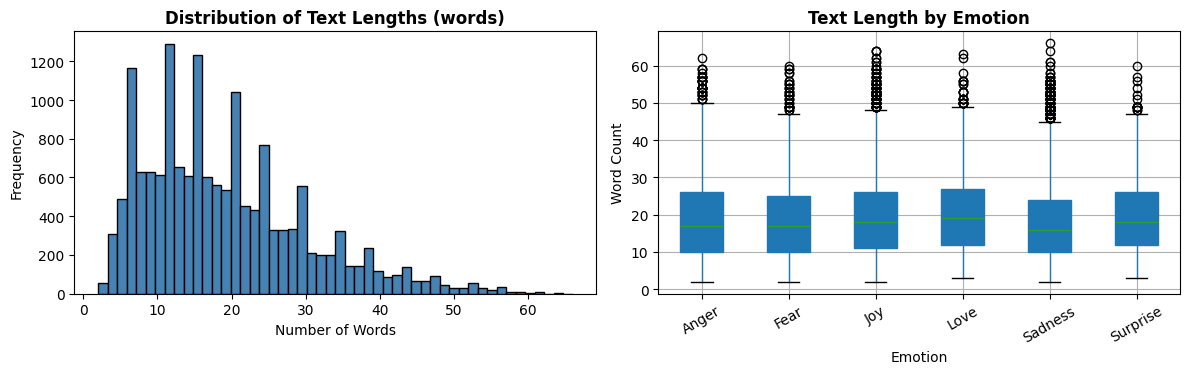


Text length stats:
count    16000.000000
mean        19.166313
std         10.986905
min          2.000000
25%         11.000000
50%         17.000000
75%         25.000000
max         66.000000
Name: text_length, dtype: float64

95th percentile word count: 41


In [6]:
train_df['text_length'] = train_df['text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(train_df['text_length'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Text Lengths (words)', fontweight='bold')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
train_df.boxplot(column='text_length', by='emotion', ax=plt.gca(),
                 patch_artist=True)
plt.title('Text Length by Emotion', fontweight='bold')
plt.suptitle('')
plt.xlabel('Emotion')
plt.ylabel('Word Count')
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig('text_length_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nText length stats:")
print(train_df['text_length'].describe())
print(f"\n95th percentile word count: {train_df['text_length'].quantile(0.95):.0f}")


### Word Cloud per emotion

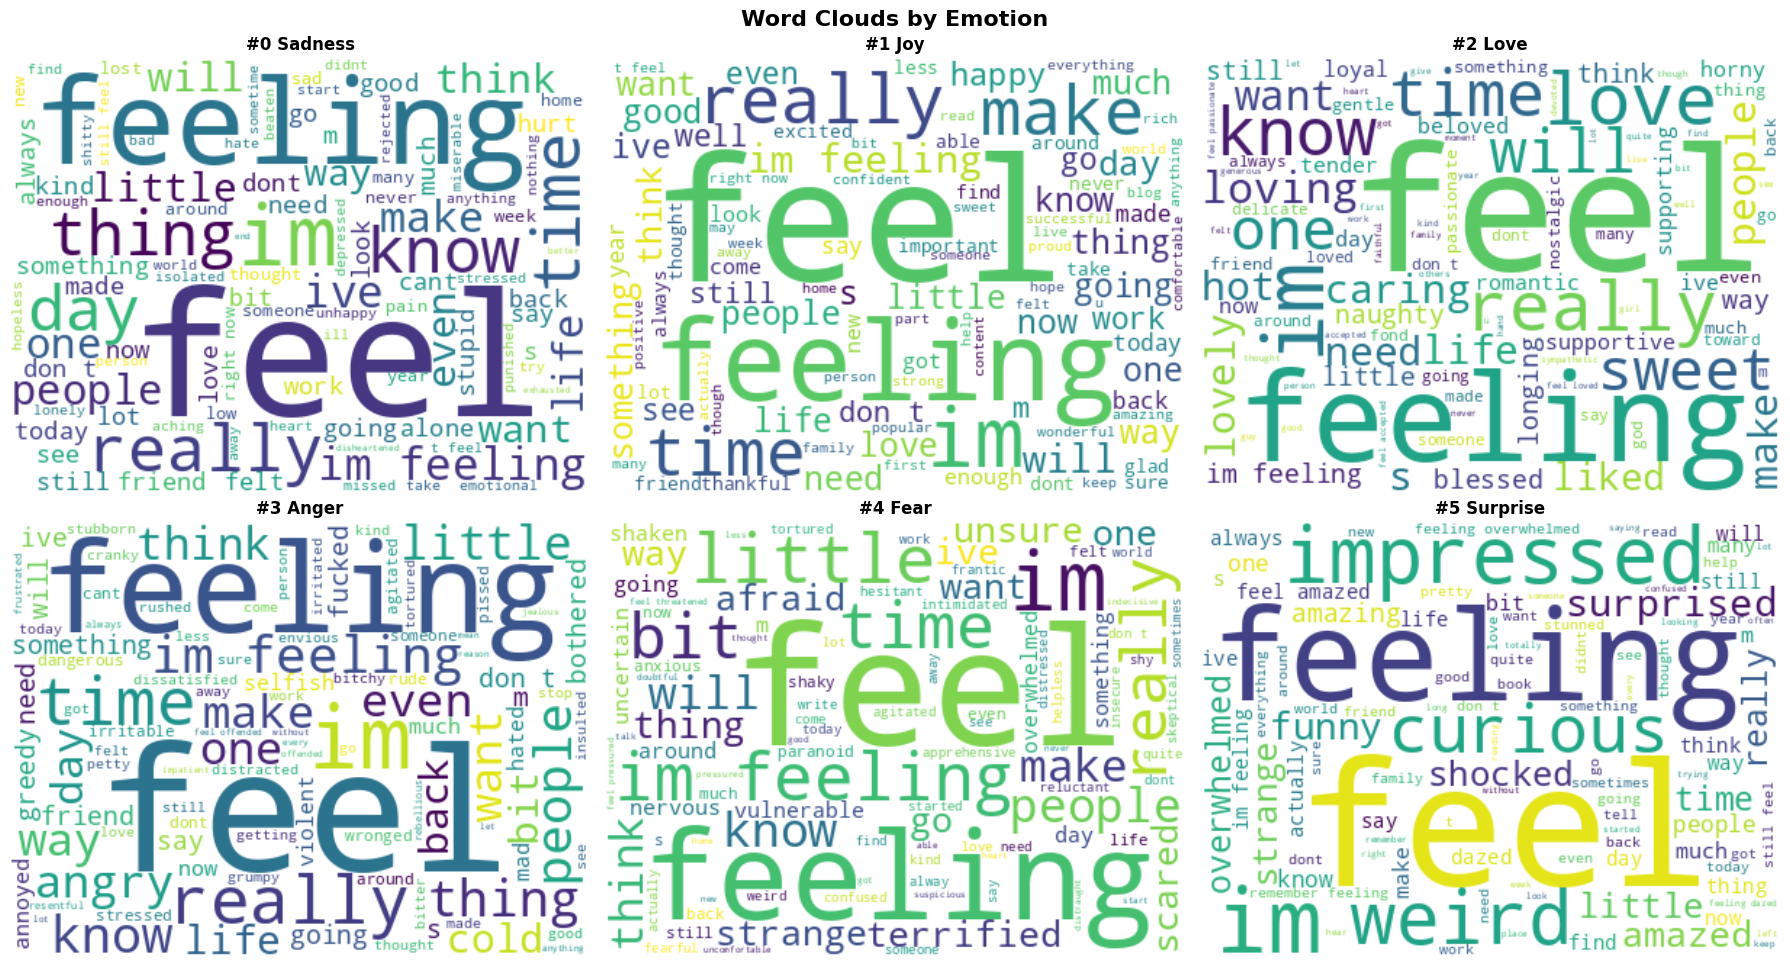

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Word Clouds by Emotion', fontsize=16, fontweight='bold')

for ax, (label, emotion) in zip(axes.flatten(), EMOTION_MAP.items()):
    subset = train_df[train_df['label'] == label]['text'].str.cat(sep=' ')
    wc = WordCloud(width=400, height=300, background_color='white',
                   colormap='viridis', max_words=100).generate(subset)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'#{label} {emotion}', fontweight='bold', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

#  STEP 3 — Text Preprocessing

In [8]:
STOP_WORDS = set(stopwords.words('english'))

def clean_text(text, remove_stopwords=True):
    """
    Full text cleaning pipeline:
    1. Lowercase
    2. Remove URLs
    3. Remove emojis & special characters
    4. Remove numbers
    5. Remove punctuation
    6. Remove extra whitespace
    7. Optional stopword removal
    """
    # 1. Lowercase
    text = text.lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 3. Remove emojis and non-ASCII characters
    text = text.encode('ascii', 'ignore').decode('ascii')

    # 4. Remove HTML tags (if any)
    text = re.sub(r'<.*?>', '', text)

    # 5. Remove numbers
    text = re.sub(r'\d+', '', text)

    # 6. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 7. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # 8. Optional: Remove stopwords (keep emotional words like "not", "no")
    if remove_stopwords:
        # Keep negation words — important for emotion
        keep_words = {'not', 'no', 'never', 'nor', 'neither', 'nothing',
                      'nobody', 'nowhere', 'hardly', 'barely', 'scarcely'}
        tokens = text.split()
        tokens = [w for w in tokens if w not in STOP_WORDS or w in keep_words]
        text = ' '.join(tokens)

    return text

# Apply preprocessing to all splits
print("🔄 Preprocessing text data...")
train_df['clean_text'] = train_df['text'].apply(clean_text)
val_df['clean_text']   = val_df['text'].apply(clean_text)
test_df['clean_text']  = test_df['text'].apply(clean_text)

# Verify preprocessing
print("\nBefore vs After Preprocessing:")
print("-" * 70)
for i in range(3):
    print(f"ORIGINAL : {train_df['text'].iloc[i]}")
    print(f"CLEANED  : {train_df['clean_text'].iloc[i]}")
    print("-" * 70)

print("✅ Preprocessing complete!")

🔄 Preprocessing text data...

Before vs After Preprocessing:
----------------------------------------------------------------------
ORIGINAL : i didnt feel humiliated
CLEANED  : didnt feel humiliated
----------------------------------------------------------------------
ORIGINAL : i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
CLEANED  : go feeling hopeless damned hopeful around someone cares awake
----------------------------------------------------------------------
ORIGINAL : im grabbing a minute to post i feel greedy wrong
CLEANED  : im grabbing minute post feel greedy wrong
----------------------------------------------------------------------
✅ Preprocessing complete!


#  STEP 4 — Tokenization & Sequence Padding

### Hyperparameters

In [9]:
# Hyperparameters
MAX_VOCAB_SIZE = 20000    # Top N most frequent words
MAX_SEQ_LEN    = 60       # Based on 95th percentile from EDA
EMBED_DIM      = 128      # Embedding dimensions
OOV_TOKEN      = '<OOV>'  # Out-of-vocabulary token


###  Fit Tokenizer on training data ONLY

In [10]:
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(train_df['clean_text'])

VOCAB_SIZE = min(MAX_VOCAB_SIZE, len(tokenizer.word_index) + 1)
print(f"Total unique words in training corpus : {len(tokenizer.word_index)}")
print(f"Vocabulary size used                  : {VOCAB_SIZE}")

Total unique words in training corpus : 15065
Vocabulary size used                  : 15066


### converting text to sequence

In [11]:
X_train = tokenizer.texts_to_sequences(train_df['clean_text'])
X_val   = tokenizer.texts_to_sequences(val_df['clean_text'])
X_test  = tokenizer.texts_to_sequences(test_df['clean_text'])

### pad sequences

In [12]:
X_train = pad_sequences(X_train, maxlen=MAX_SEQ_LEN, padding='post', truncating='post')
X_val   = pad_sequences(X_val,   maxlen=MAX_SEQ_LEN, padding='post', truncating='post')
X_test  = pad_sequences(X_test,  maxlen=MAX_SEQ_LEN, padding='post', truncating='post')

print(f"\nPadded sequence shapes:")
print(f"  X_train : {X_train.shape}")
print(f"  X_val   : {X_val.shape}")
print(f"  X_test  : {X_test.shape}")


Padded sequence shapes:
  X_train : (16000, 60)
  X_val   : (2000, 60)
  X_test  : (2000, 60)


## Label encoding

In [13]:
NUM_CLASSES = len(EMOTION_MAP)

y_train = train_df['label'].values
y_val   = val_df['label'].values
y_test  = test_df['label'].values

# For multi-class: use sparse labels with sparse_categorical_crossentropy
# OR convert to one-hot with categorical_crossentropy
y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_val_cat   = to_categorical(y_val,   num_classes=NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  num_classes=NUM_CLASSES)

print(f"\nLabel shapes:")
print(f"  y_train : {y_train_cat.shape}")
print(f"  y_val   : {y_val_cat.shape}")
print(f"  y_test  : {y_test_cat.shape}")
print(f"  Classes : {NUM_CLASSES}  →  {list(EMOTION_MAP.values())}")

# Show sample tokenized sequence
print("\nSample tokenized + padded sequence:")
print(f"Text    : {train_df['clean_text'].iloc[0]}")
print(f"Tokens  : {X_train[0][:20]}...")


Label shapes:
  y_train : (16000, 6)
  y_val   : (2000, 6)
  y_test  : (2000, 6)
  Classes : 6  →  ['Sadness', 'Joy', 'Love', 'Anger', 'Fear', 'Surprise']

Sample tokenized + padded sequence:
Text    : didnt feel humiliated
Tokens  : [ 52   2 565   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0]...


#  STEP 5 — Build Models (LSTM & GRU)

In [14]:
def build_lstm_model(vocab_size, embed_dim, max_len, num_classes,
                     spatial_dropout=0.2, lstm_units=128,
                     dense_units=64, dropout_rate=0.3):
    """
    Bidirectional LSTM Model Architecture:
    Input → Embedding → SpatialDropout → BiLSTM → Dropout → Dense → Output
    """
    model = Sequential([
        # Embedding layer: converts word indices to dense vectors
        Embedding(input_dim=vocab_size,
                  output_dim=embed_dim,
                  input_length=max_len,
                  name='embedding'),

        # Spatial dropout on embedding (drops entire feature maps)
        SpatialDropout1D(spatial_dropout, name='spatial_dropout'),

        # Bidirectional LSTM (captures both forward & backward context)
        Bidirectional(LSTM(lstm_units, return_sequences=True,
                           dropout=0.2, recurrent_dropout=0.2),
                      name='bi_lstm_1'),

        # Second LSTM layer for deeper learning
        Bidirectional(LSTM(lstm_units // 2, return_sequences=False,
                           dropout=0.2, recurrent_dropout=0.2),
                      name='bi_lstm_2'),

        # Dropout for regularization
        Dropout(dropout_rate, name='dropout_1'),

        # Dense hidden layer
        Dense(dense_units, activation='relu', name='dense_1'),
        Dropout(dropout_rate / 2, name='dropout_2'),

        # Output layer: softmax for multi-class classification
        Dense(num_classes, activation='softmax', name='output')
    ], name='BiLSTM_EmotionDetector')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def build_gru_model(vocab_size, embed_dim, max_len, num_classes,
                    spatial_dropout=0.2, gru_units=128,
                    dense_units=64, dropout_rate=0.3):
    """
    Bidirectional GRU Model Architecture:
    Input → Embedding → SpatialDropout → BiGRU → Dropout → Dense → Output
    GRU is faster than LSTM with comparable performance.
    """
    model = Sequential([
        Embedding(input_dim=vocab_size,
                  output_dim=embed_dim,
                  input_length=max_len,
                  name='embedding'),

        SpatialDropout1D(spatial_dropout, name='spatial_dropout'),

        # Stacked Bidirectional GRU
        Bidirectional(GRU(gru_units, return_sequences=True,
                          dropout=0.2, recurrent_dropout=0.2),
                      name='bi_gru_1'),

        Bidirectional(GRU(gru_units // 2, return_sequences=False,
                          dropout=0.2, recurrent_dropout=0.2),
                      name='bi_gru_2'),

        Dropout(dropout_rate, name='dropout_1'),
        Dense(dense_units, activation='relu', name='dense_1'),
        Dropout(dropout_rate / 2, name='dropout_2'),
        Dense(num_classes, activation='softmax', name='output')
    ], name='BiGRU_EmotionDetector')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# Instantiate both models
lstm_model = build_lstm_model(VOCAB_SIZE, EMBED_DIM, MAX_SEQ_LEN, NUM_CLASSES)
gru_model  = build_gru_model(VOCAB_SIZE, EMBED_DIM, MAX_SEQ_LEN, NUM_CLASSES)

print("=" * 60)
print("📐 LSTM MODEL SUMMARY")
print("=" * 60)
lstm_model.summary()

print("\n" + "=" * 60)
print("📐 GRU MODEL SUMMARY")
print("=" * 60)
gru_model.summary()

📐 LSTM MODEL SUMMARY


Model: "BiLSTM_EmotionDetector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bi_lstm_1 (Bidirectional)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bi_lstm_2 (Bidirectional)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

Model: "BiGRU_EmotionDetector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bi_gru_1 (Bidirectional)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bi_gru_2 (Bidirectional)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### STEP 6 — Training Callbacks & Train Both Models

In [15]:
EPOCHS     = 20
BATCH_SIZE = 64

def get_callbacks(model_name):
    """Training callbacks: EarlyStopping + ModelCheckpoint + LR Scheduler"""
    return [
        EarlyStopping(
            monitor='val_accuracy',
            patience=4,
            restore_best_weights=True,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=f'best_{model_name}.keras',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=0
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1
        )
    ]


# ── Train LSTM ─────────────────────────────────────────────
print("🚀 Training Bidirectional LSTM Model...")
print("=" * 60)

lstm_history = lstm_model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks('lstm'),
    verbose=1
)

# ── Train GRU ──────────────────────────────────────────────
print("\n🚀 Training Bidirectional GRU Model...")
print("=" * 60)

gru_history = gru_model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks('gru'),
    verbose=1
)

print("\n✅ Training complete for both models!")

🚀 Training Bidirectional LSTM Model...
Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 146s 515ms/step - accuracy: 0.4819 - loss: 1.3011 - val_accuracy: 0.7755 - val_loss: 0.6280 - learning_rate: 0.0010
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 130s 519ms/step - accuracy: 0.8594 - loss: 0.4081 - val_accuracy: 0.8935 - val_loss: 0.3072 - learning_rate: 0.0010
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 142s 569ms/step - accuracy: 0.9383 - loss: 0.1845 - val_accuracy: 0.9155 - val_loss: 0.2564 - learning_rate: 0.0010
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 131s 521ms/step - accuracy: 0.9628 - loss: 0.1195 - val_accuracy: 0.9120 - val_loss: 0.2716 - learning_rate: 0.0010
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.9709 - loss: 0.0886
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 ━━━━━━━━━━━━━━━━━━━━ 124s 497ms/step - accuracy: 0.9707 - loss: 0.0860 - val_accuracy: 0.9155 - val_loss: 0.2707 - learning_rate: 0.0010
Epoch 6/20
250/250 ━━━━━━━━━

# step 7 Plot Training Curves

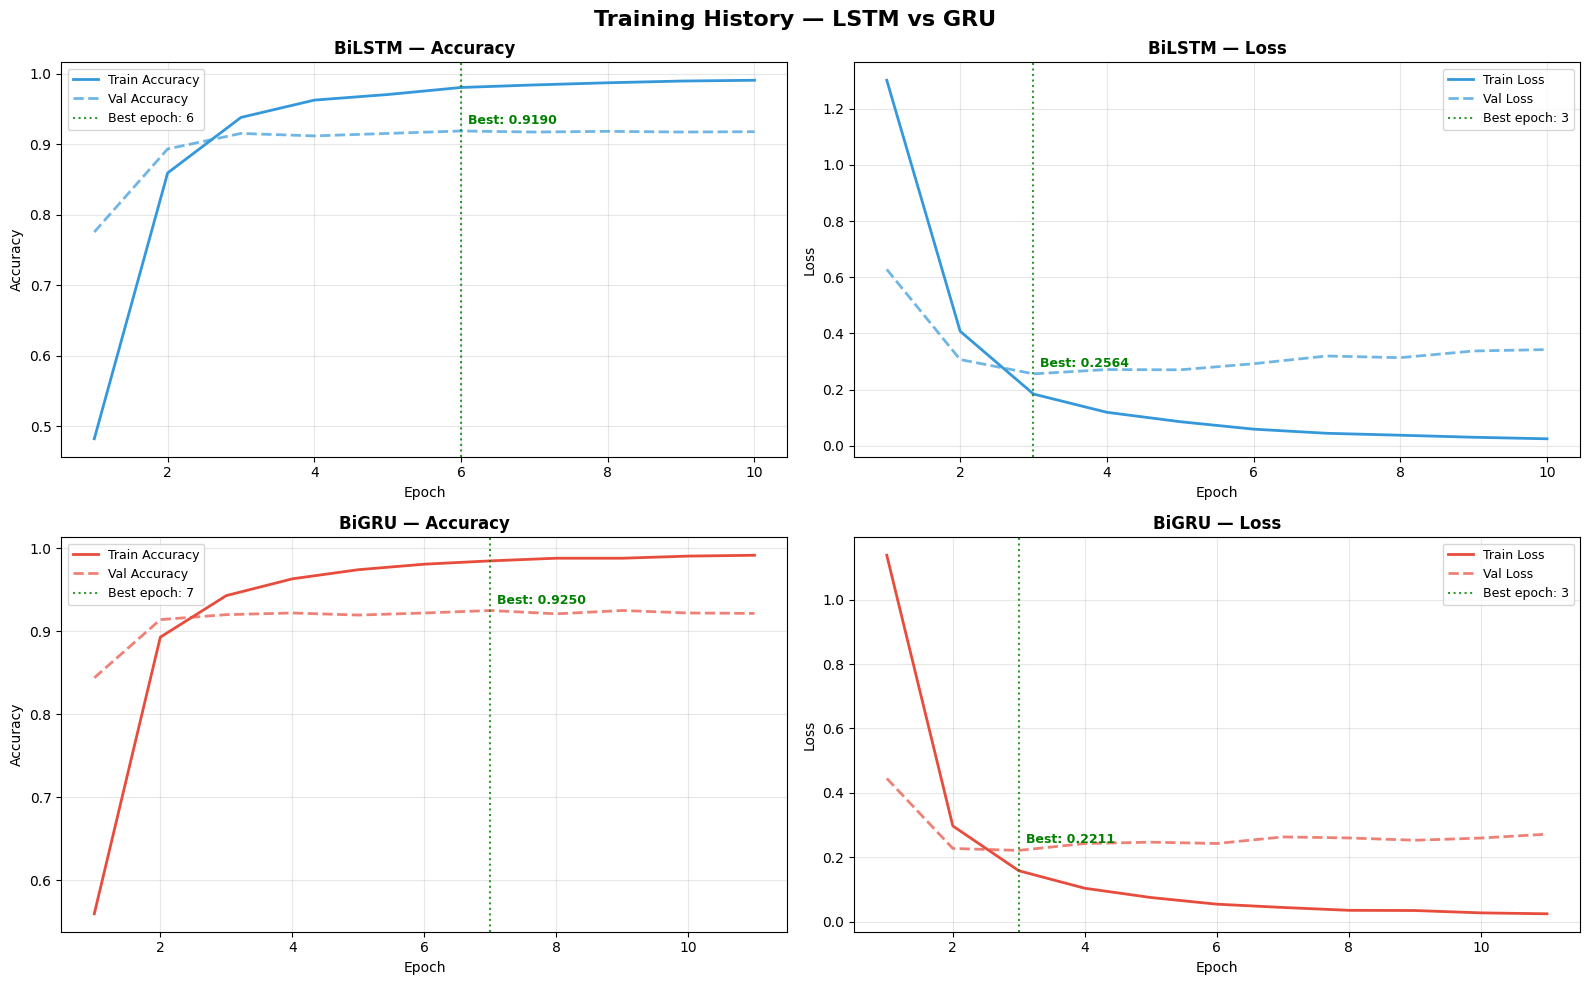

In [16]:
def plot_training_history(lstm_hist, gru_hist):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Training History — LSTM vs GRU', fontsize=16, fontweight='bold')

    metrics = [('accuracy', 'val_accuracy', 'Accuracy'),
               ('loss',     'val_loss',     'Loss')]

    for col, (train_key, val_key, title) in enumerate(metrics):
        for row, (hist, model_name, color) in enumerate(
                [(lstm_hist, 'BiLSTM', '#3498db'),
                 (gru_hist,  'BiGRU',  '#e74c3c')]):

            ax = axes[row][col]
            epochs_ran = range(1, len(hist.history[train_key]) + 1)

            ax.plot(epochs_ran, hist.history[train_key],
                    color=color, linewidth=2, label=f'Train {title}')
            ax.plot(epochs_ran, hist.history[val_key],
                    color=color, linewidth=2, linestyle='--',
                    label=f'Val {title}', alpha=0.7)

            best_epoch = (np.argmax(hist.history[val_key]) if 'acc' in val_key
                          else np.argmin(hist.history[val_key])) + 1
            best_val   = (max(hist.history[val_key]) if 'acc' in val_key
                          else min(hist.history[val_key]))

            ax.axvline(x=best_epoch, color='green', linestyle=':', alpha=0.8,
                       label=f'Best epoch: {best_epoch}')
            ax.set_title(f'{model_name} — {title}', fontweight='bold')
            ax.set_xlabel('Epoch')
            ax.set_ylabel(title)
            ax.legend(fontsize=9)
            ax.grid(alpha=0.3)
            ax.annotate(f'Best: {best_val:.4f}', xy=(best_epoch, best_val),
                        xytext=(5, 5), textcoords='offset points', fontsize=9,
                        color='green', fontweight='bold')

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_training_history(lstm_history, gru_history)

# STEP 8 — Evaluate on Test Set


📊 Evaluating: BiLSTM
Test Loss     : 0.3011
Test Accuracy : 0.9190  (91.90%)
Weighted F1   : 0.9199

Classification Report:
              precision    recall  f1-score   support

     Sadness     0.9647    0.9398    0.9520       581
         Joy     0.9408    0.9381    0.9395       695
        Love     0.7907    0.8553    0.8218       159
       Anger     0.9438    0.9164    0.9299       275
        Fear     0.8767    0.8884    0.8825       224
    Surprise     0.7067    0.8030    0.7518        66

    accuracy                         0.9190      2000
   macro avg     0.8706    0.8902    0.8796      2000
weighted avg     0.9213    0.9190    0.9199      2000



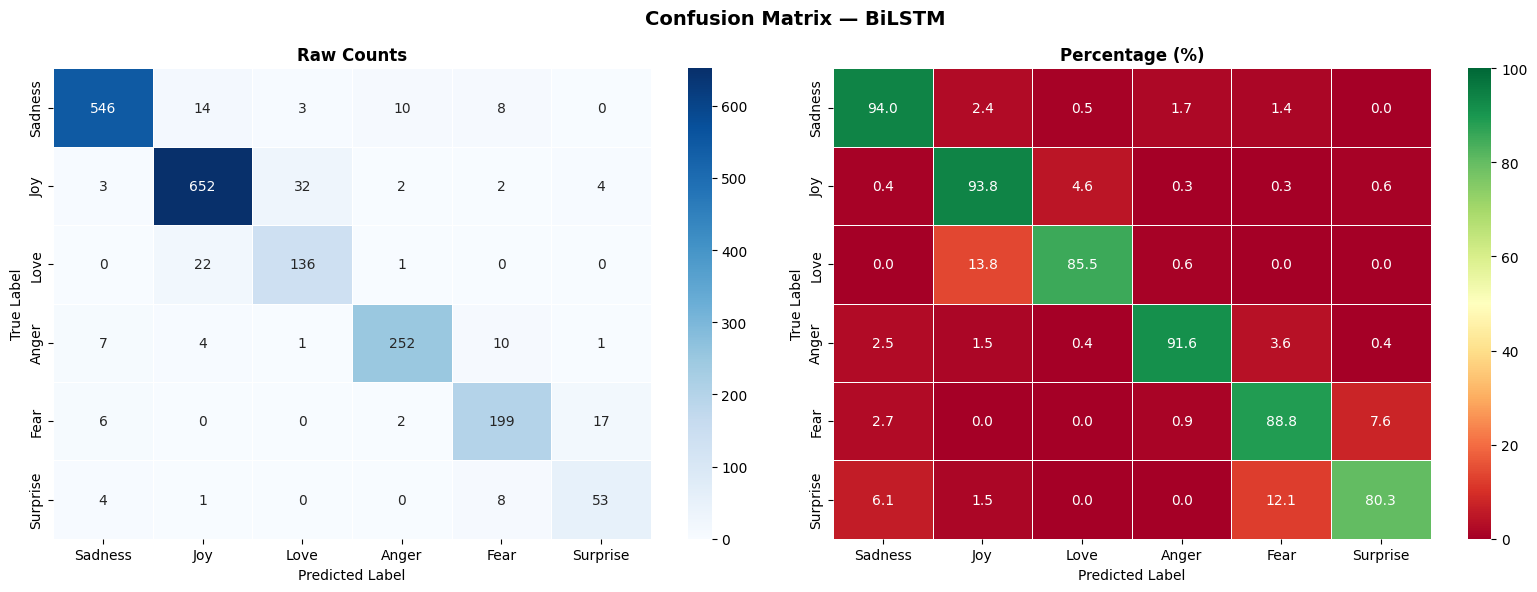


📊 Evaluating: BiGRU
Test Loss     : 0.2712
Test Accuracy : 0.9180  (91.80%)
Weighted F1   : 0.9196

Classification Report:
              precision    recall  f1-score   support

     Sadness     0.9804    0.9466    0.9632       581
         Joy     0.9625    0.9223    0.9420       695
        Love     0.7421    0.8868    0.8080       159
       Anger     0.8874    0.9455    0.9155       275
        Fear     0.8957    0.8438    0.8690       224
    Surprise     0.6962    0.8333    0.7586        66

    accuracy                         0.9180      2000
   macro avg     0.8607    0.8964    0.8760      2000
weighted avg     0.9236    0.9180    0.9196      2000



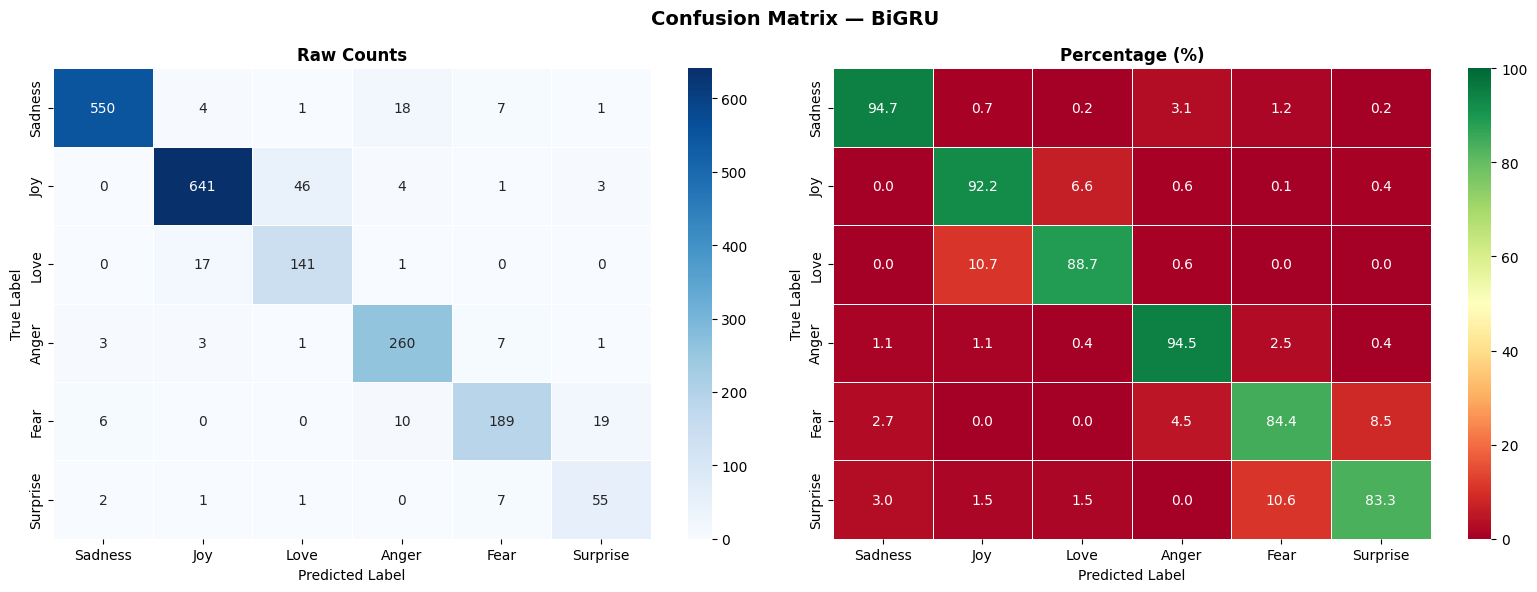

In [17]:
def evaluate_model(model, X_test, y_test_cat, y_test_raw,
                   model_name, emotion_names):
    print(f"\n{'='*60}")
    print(f"📊 Evaluating: {model_name}")
    print(f"{'='*60}")

    # Predictions
    y_pred_proba = model.predict(X_test, verbose=0)
    y_pred       = np.argmax(y_pred_proba, axis=1)

    # Test loss & accuracy
    loss, acc = model.evaluate(X_test, y_test_cat, verbose=0)
    print(f"Test Loss     : {loss:.4f}")
    print(f"Test Accuracy : {acc:.4f}  ({acc*100:.2f}%)")

    # F1-Score (weighted)
    f1 = f1_score(y_test_raw, y_pred, average='weighted')
    print(f"Weighted F1   : {f1:.4f}")

    # Per-class Classification Report
    print(f"\nClassification Report:")
    print(classification_report(y_test_raw, y_pred,
                                target_names=emotion_names,
                                digits=4))
    return y_pred, y_pred_proba


def plot_confusion_matrix(y_true, y_pred, emotion_names, model_name):
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Confusion Matrix — {model_name}', fontsize=14, fontweight='bold')

    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=emotion_names, yticklabels=emotion_names,
                ax=axes[0], linewidths=0.5)
    axes[0].set_title('Raw Counts', fontweight='bold')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')

    # Percentage
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='RdYlGn',
                xticklabels=emotion_names, yticklabels=emotion_names,
                ax=axes[1], linewidths=0.5, vmin=0, vmax=100)
    axes[1].set_title('Percentage (%)', fontweight='bold')
    axes[1].set_ylabel('True Label')
    axes[1].set_xlabel('Predicted Label')

    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{model_name.lower()}.png', dpi=150,
                bbox_inches='tight')
    plt.show()


EMOTION_NAMES = list(EMOTION_MAP.values())

# Evaluate LSTM
lstm_preds, lstm_proba = evaluate_model(
    lstm_model, X_test, y_test_cat, y_test, 'BiLSTM', EMOTION_NAMES)
plot_confusion_matrix(y_test, lstm_preds, EMOTION_NAMES, 'BiLSTM')

# Evaluate GRU
gru_preds, gru_proba = evaluate_model(
    gru_model, X_test, y_test_cat, y_test, 'BiGRU', EMOTION_NAMES)
plot_confusion_matrix(y_test, gru_preds, EMOTION_NAMES, 'BiGRU')

#  STEP 9 — Model Comparison


📊 Model Comparison Table:
        Test Accuracy  Weighted F1  Macro F1  Test Loss
Model                                                  
BiLSTM          0.919       0.9199    0.8796     0.3011
BiGRU           0.918       0.9196    0.8760     0.2712


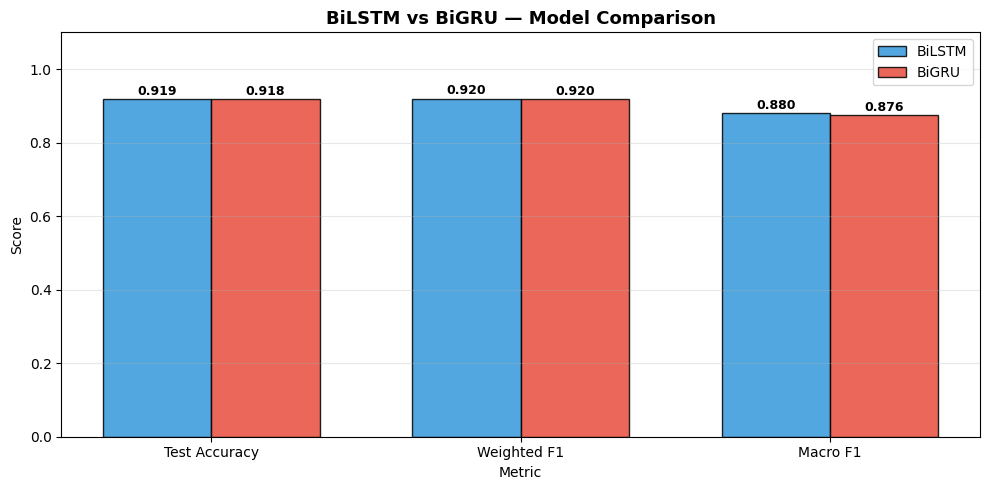

In [18]:
def compare_models(models_data):
    """
    models_data: list of (model, X_test, y_test_cat, y_test_raw, name)
    """
    results = []
    for model, X, y_cat, y_raw, name in models_data:
        loss, acc = model.evaluate(X, y_cat, verbose=0)
        y_pred = np.argmax(model.predict(X, verbose=0), axis=1)
        f1_w = f1_score(y_raw, y_pred, average='weighted')
        f1_m = f1_score(y_raw, y_pred, average='macro')
        results.append({'Model': name, 'Test Accuracy': acc,
                        'Weighted F1': f1_w, 'Macro F1': f1_m,
                        'Test Loss': loss})

    df_results = pd.DataFrame(results).set_index('Model')
    print("\n📊 Model Comparison Table:")
    print(df_results.round(4).to_string())

    # Bar chart comparison
    metrics = ['Test Accuracy', 'Weighted F1', 'Macro F1']
    x = np.arange(len(metrics))
    width = 0.35
    colors_list = ['#3498db', '#e74c3c']

    fig, ax = plt.subplots(figsize=(10, 5))
    for i, (model_name, row) in enumerate(df_results.iterrows()):
        bars = ax.bar(x + i*width, [row[m] for m in metrics],
                      width, label=model_name, color=colors_list[i],
                      alpha=0.85, edgecolor='black')
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                    f'{bar.get_height():.3f}', ha='center', va='bottom',
                    fontsize=9, fontweight='bold')

    ax.set_xlabel('Metric')
    ax.set_ylabel('Score')
    ax.set_title('BiLSTM vs BiGRU — Model Comparison', fontweight='bold', fontsize=13)
    ax.set_xticks(x + width/2)
    ax.set_xticklabels(metrics)
    ax.set_ylim(0, 1.1)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    return df_results

comparison = compare_models([
    (lstm_model, X_test, y_test_cat, y_test, 'BiLSTM'),
    (gru_model,  X_test, y_test_cat, y_test, 'BiGRU'),
])

# STEP 10 — Per-Class F1 Score Visualization

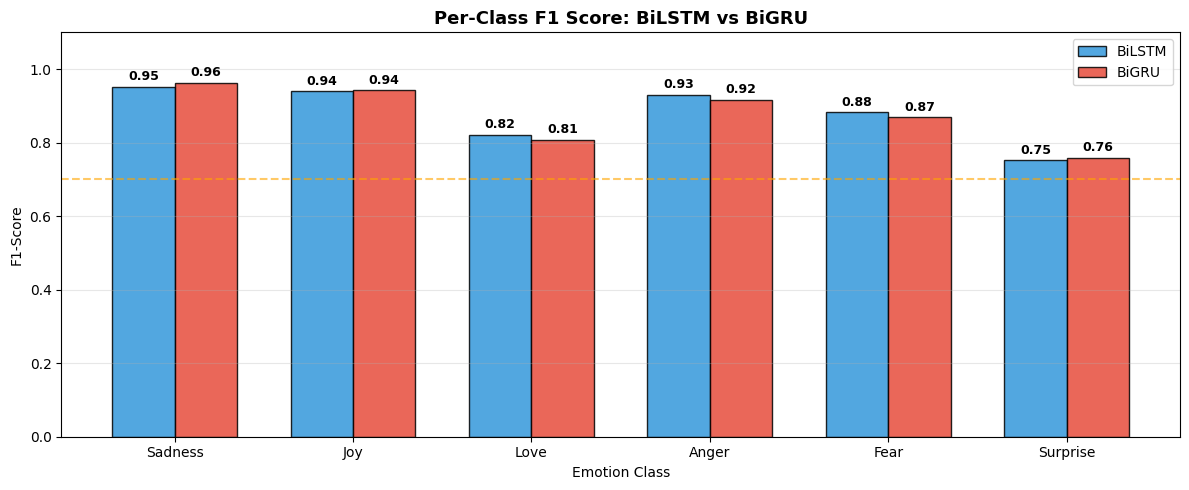

In [19]:
from sklearn.metrics import f1_score

def plot_per_class_f1(y_true, lstm_pred, gru_pred, emotion_names):
    lstm_f1 = f1_score(y_true, lstm_pred, average=None)
    gru_f1  = f1_score(y_true, gru_pred,  average=None)

    x = np.arange(len(emotion_names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 5))
    b1 = ax.bar(x - width/2, lstm_f1, width, label='BiLSTM',
                color='#3498db', alpha=0.85, edgecolor='black')
    b2 = ax.bar(x + width/2, gru_f1,  width, label='BiGRU',
                color='#e74c3c', alpha=0.85, edgecolor='black')

    for bar in list(b1) + list(b2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

    ax.set_xlabel('Emotion Class')
    ax.set_ylabel('F1-Score')
    ax.set_title('Per-Class F1 Score: BiLSTM vs BiGRU', fontweight='bold', fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(emotion_names)
    ax.set_ylim(0, 1.1)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(y=0.7, color='orange', linestyle='--', alpha=0.6, label='70% threshold')

    plt.tight_layout()
    plt.savefig('per_class_f1.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_per_class_f1(y_test, lstm_preds, gru_preds, EMOTION_NAMES)

# STEP 11: Manual Testing — Predict Emotions from Custom Text

In [20]:
def predict_emotion(text, model, tokenizer, max_len=MAX_SEQ_LEN,
                    emotion_map=EMOTION_MAP, top_k=3):
    """
    Predict emotion from a raw user-input sentence.
    Returns top-k emotions with confidence scores.
    """
    # Preprocess
    cleaned = clean_text(text)

    # Tokenize & pad
    seq = tokenizer.texts_to_sequences([cleaned])
    seq = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')

    # Predict
    proba = model.predict(seq, verbose=0)[0]
    pred_label = np.argmax(proba)

    # Sort by confidence
    sorted_idx = np.argsort(proba)[::-1]

    print(f"\n{'='*55}")
    print(f"📝 Input    : {text}")
    print(f"🧹 Cleaned  : {cleaned}")
    print(f"{'─'*55}")
    print(f"🎯 Predicted Emotion: {emotion_map[pred_label].upper()}  "
          f"({proba[pred_label]*100:.2f}%)")
    print(f"\n📊 Top-{top_k} Emotions:")
    for rank, idx in enumerate(sorted_idx[:top_k], 1):
        bar = '█' * int(proba[idx] * 30)
        print(f"  {rank}. {emotion_map[idx]:<10} {bar:<30} {proba[idx]*100:5.2f}%")
    print(f"{'='*55}")
    return emotion_map[pred_label], proba


# ── Select best model ──────────────────────────────────────
# Pick the model with better test accuracy
lstm_acc = lstm_model.evaluate(X_test, y_test_cat, verbose=0)[1]
gru_acc  = gru_model.evaluate(X_test, y_test_cat, verbose=0)[1]
best_model = lstm_model if lstm_acc >= gru_acc else gru_model
best_name  = 'BiLSTM' if lstm_acc >= gru_acc else 'BiGRU'
print(f"\n🏆 Best Model: {best_name} (Test Accuracy: {max(lstm_acc, gru_acc):.4f})")

# ── Test custom sentences ──────────────────────────────────
test_sentences = [
    "I am so happy today, everything is going great!",
    "I feel so sad and lonely, no one understands me.",
    "This makes me absolutely furious, how dare they!",
    "I'm terrified about what might happen next.",
    "Oh wow, I never expected that to happen at all!",
    "I don't really feel anything special about this.",
    "I love spending time with my family, it's wonderful.",
    "I'm feeling quite disappointed after today's results.",
    "The thought of losing my job fills me with dread.",
    "I feel so grateful and blessed to have you in my life."
]

print(f"\n🔍 Manual Testing with {best_name} Model\n")
for sentence in test_sentences:
    predict_emotion(sentence, best_model, tokenizer)


🏆 Best Model: BiLSTM (Test Accuracy: 0.9190)

🔍 Manual Testing with BiLSTM Model


📝 Input    : I am so happy today, everything is going great!
🧹 Cleaned  : happy today everything going great
───────────────────────────────────────────────────────
🎯 Predicted Emotion: JOY  (98.05%)

📊 Top-3 Emotions:
  1. Joy        █████████████████████████████  98.05%
  2. Sadness                                    0.96%
  3. Fear                                       0.38%

📝 Input    : I feel so sad and lonely, no one understands me.
🧹 Cleaned  : feel sad lonely no one understands
───────────────────────────────────────────────────────
🎯 Predicted Emotion: SADNESS  (99.98%)

📊 Top-3 Emotions:
  1. Sadness    █████████████████████████████  99.98%
  2. Anger                                      0.01%
  3. Joy                                        0.00%

📝 Input    : This makes me absolutely furious, how dare they!
🧹 Cleaned  : makes absolutely furious dare
──────────────────────────────────────────

# STEP 12 — Save Models & Tokenizer

In [21]:
import pickle, json
from google.colab import files

# --- Save models locally in Colab ---
lstm_model.save('lstm_emotion_model.keras')
print('✅ LSTM model saved as: lstm_emotion_model.keras')

gru_model.save('gru_emotion_model.keras')
print('✅ GRU model saved as: gru_emotion_model.keras')

# --- Save tokenizer ---
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print('✅ Tokenizer saved as: tokenizer.pkl')

# --- Save config ---
config = {
    'MAX_VOCAB_SIZE': MAX_VOCAB_SIZE,
    'MAX_SEQ_LEN': MAX_SEQ_LEN,
    'EMBED_DIM': EMBED_DIM,
    'NUM_CLASSES': NUM_CLASSES,
    'EMOTION_MAP': EMOTION_MAP,
    'best_model': best_name
}
with open('emotion_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print('✅ Config saved as: emotion_config.json')

print('\n📥 Now downloading all files to your computer...')

# --- Download to your computer ---
files.download('lstm_emotion_model.keras')
files.download('gru_emotion_model.keras')
files.download('tokenizer.pkl')
files.download('emotion_config.json')

print('✅ Download started! Check your Downloads folder.')

✅ LSTM model saved as: lstm_emotion_model.keras
✅ GRU model saved as: gru_emotion_model.keras
✅ Tokenizer saved as: tokenizer.pkl
✅ Config saved as: emotion_config.json

📥 Now downloading all files to your computer...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started! Check your Downloads folder.
